Import packages

In [1]:
# Third party packages.
import os

import pandas as pd             # Data handling
import polars as pl             # Data handling ('Blazingly fast DataFrames'), alternative to Pandas.
import polars.selectors as cs   # Select columns of particular type.
import numpy as np              # Numeric calculations
import pickle                   # Save and load data
import seaborn as sns           # Visualize data
import matplotlib.pyplot as plt # Visualize data

from sklearn.model_selection    import train_test_split     # Split data
from sklearn.preprocessing      import StandardScaler       # Scale data
from sklearn.linear_model       import LinearRegression     # Linear regression
from sklearn.linear_model       import LassoCV              # Lasso regression
from sklearn.preprocessing      import OneHotEncoder        # One hot encoding
from sklearn.neighbors          import KNeighborsRegressor  # KNN regression
from sklearn.model_selection    import GridSearchCV         # Grid search

from scipy.stats import pearsonr # Correlation

Import file

In [2]:

df = pl.read_parquet(f'../Experiment/Knee/prepared_datasets/pipeline1_test.parquet')
df.shape

(21739, 39)

In [3]:
df.dtypes

[UInt8,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 UInt8,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float32,
 Int64]

<Axes: >

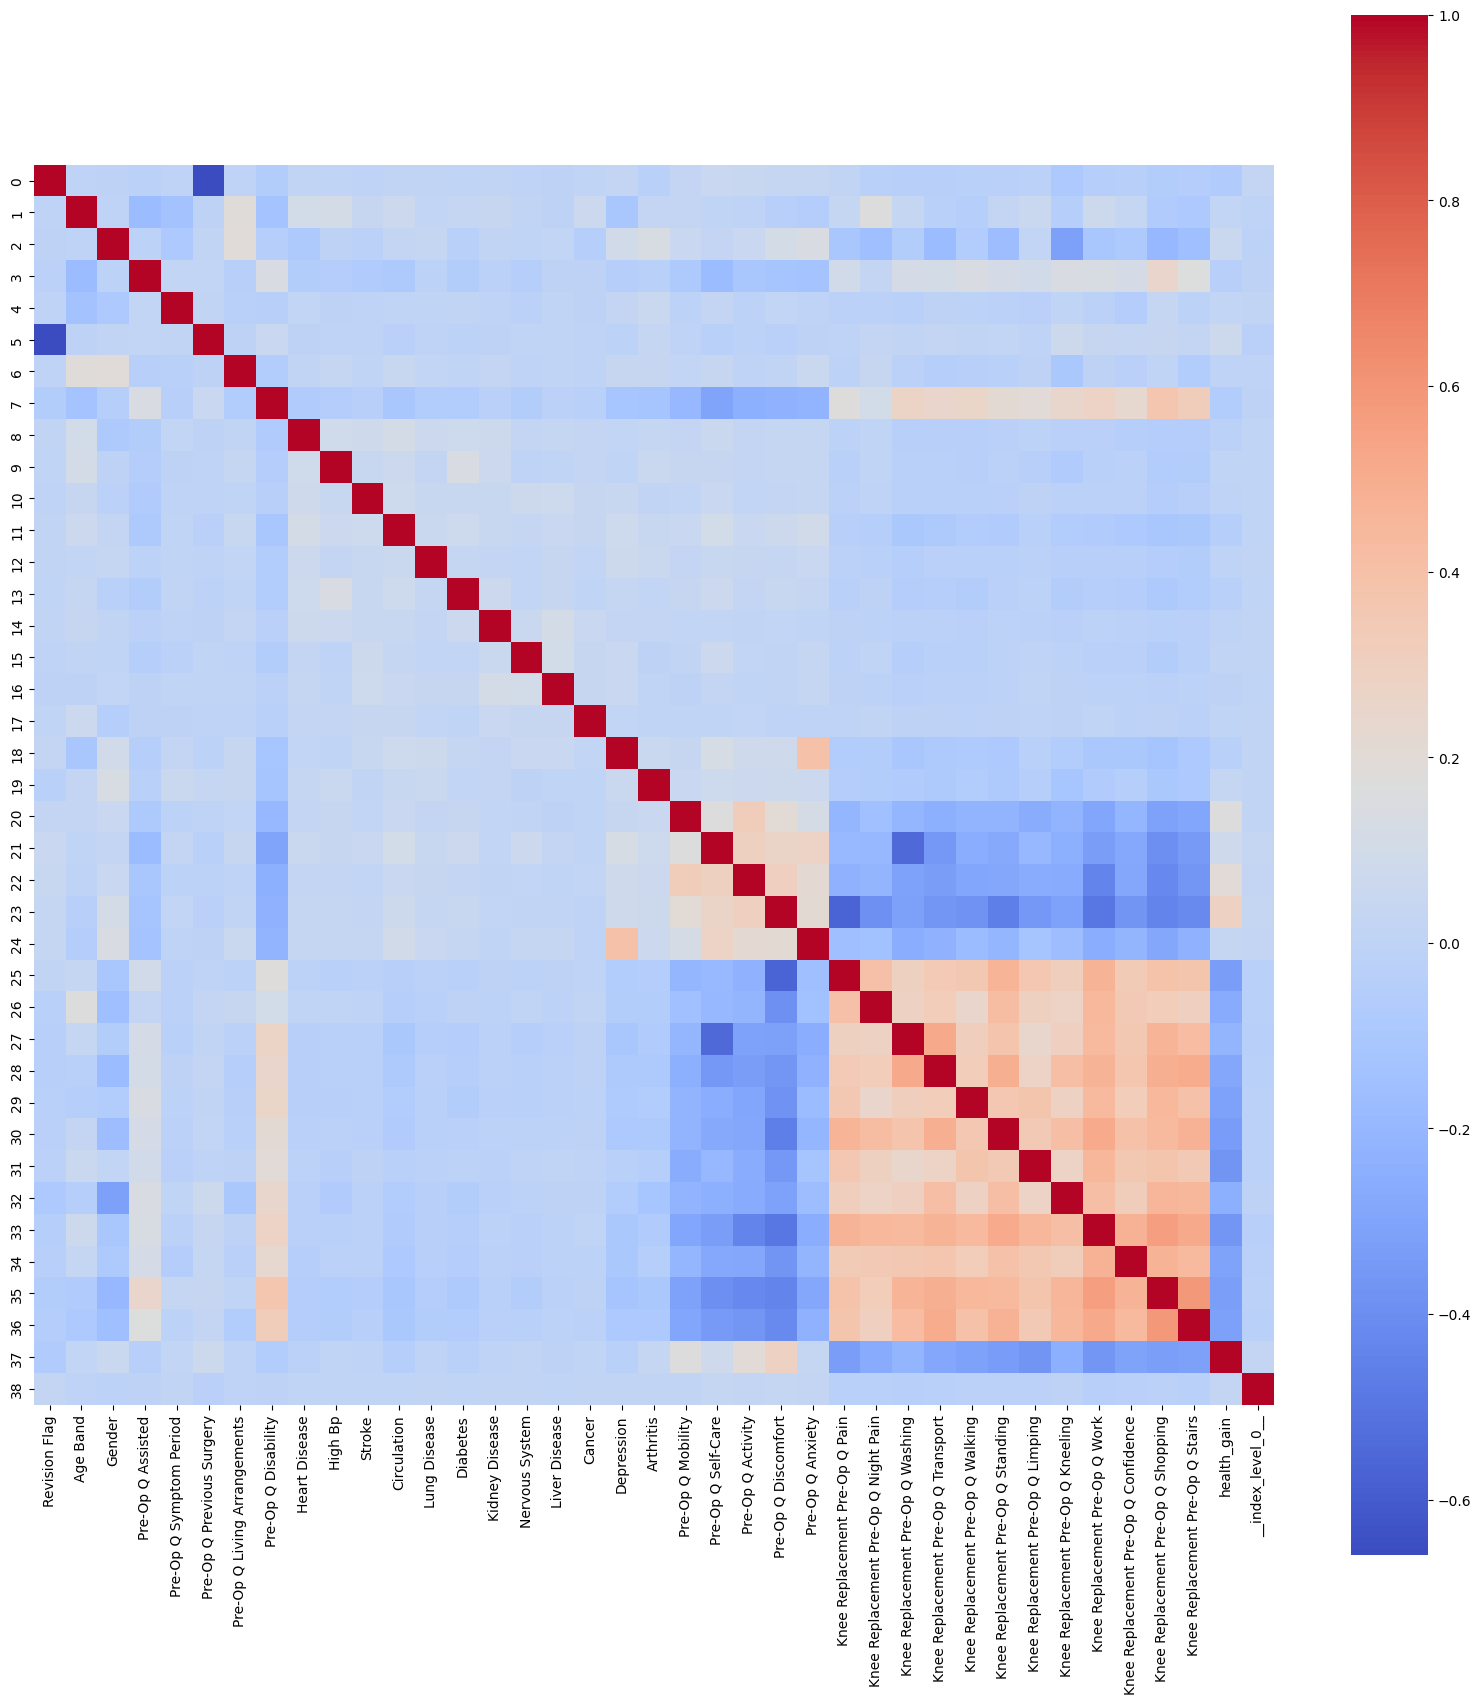

In [72]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix.to_pandas(),
    annot=False,
    square=True,
    cmap='coolwarm'
)

<Axes: >

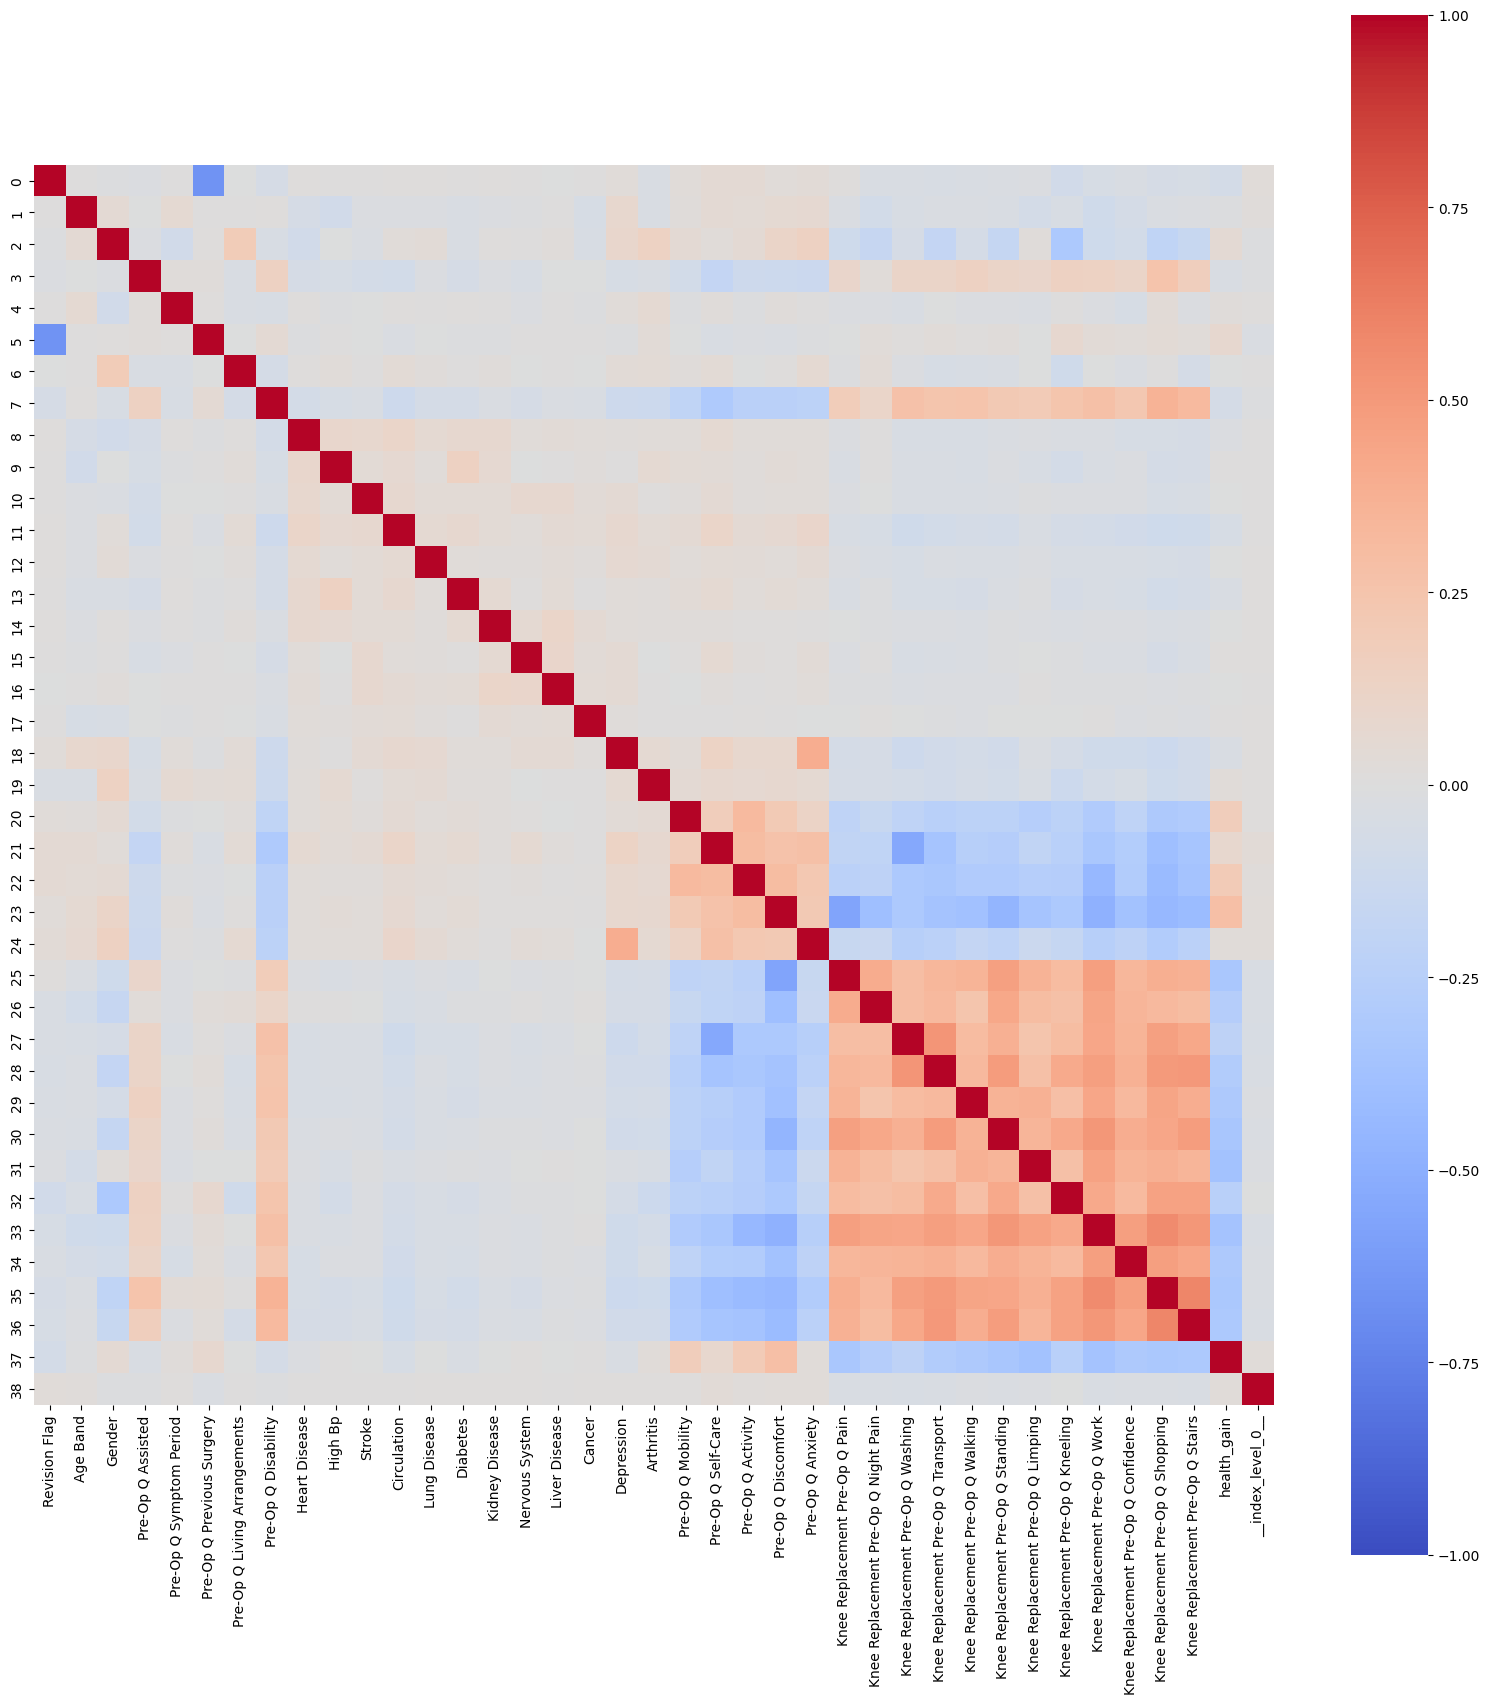

In [36]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix.to_pandas(),
    annot=False,
    square=True,
    cmap='coolwarm',
    vmin=-1,     # force full correlation range
    vmax=1,
    center=0     # ensure 0 is grey
)


In [4]:
target = "health_gain"

numeric_features = (
    df
    .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))
    .columns
)

corr_overview = df.select([
    pl.corr(pl.col(target), pl.col(feature)).alias(feature)
    for feature in numeric_features
]).transpose(include_header=True, header_name="feature", column_names=["correlation"])

corr_overview = corr_overview.sort("correlation", descending=True)

corr_overview.show(50)

print(corr_overview)




C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\1806118479.py:5: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))


feature,correlation
str,f64
"""Pre-Op Q Discomfort""",0.285882
"""Pre-Op Q Activity""",0.196738
"""Pre-Op Q Mobility""",0.17315
"""Pre-Op Q Self-Care""",0.085234
"""Pre-Op Q Previous Surgery""",0.071595
"""Gender""",0.053921
"""Arthritis""",0.030231
"""Pre-Op Q Anxiety""",0.028424
"""__index_level_0__""",0.027226


shape: (38, 2)
┌─────────────────────────────────┬─────────────┐
│ feature                         ┆ correlation │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ Pre-Op Q Discomfort             ┆ 0.285882    │
│ Pre-Op Q Activity               ┆ 0.196738    │
│ Pre-Op Q Mobility               ┆ 0.17315     │
│ Pre-Op Q Self-Care              ┆ 0.085234    │
│ Pre-Op Q Previous Surgery       ┆ 0.071595    │
│ …                               ┆ …           │
│ Knee Replacement Pre-Op Q Shop… ┆ -0.323322   │
│ Knee Replacement Pre-Op Q Pain  ┆ -0.333731   │
│ Knee Replacement Pre-Op Q Stan… ┆ -0.338922   │
│ Knee Replacement Pre-Op Q Work  ┆ -0.363248   │
│ Knee Replacement Pre-Op Q Limp… ┆ -0.37382    │
└─────────────────────────────────┴─────────────┘


In [6]:
low_corr_cols = [
    "Gender",
    "Pre-Op Q Anxiety",
    "Arthritis",
    "Age Band",
    "Pre-Op Q Symptom Period",
    "High Bp",
    "Cancer",
    "Nervous System",
    "Lung Disease",
    "Liver Disease",
    "Kidney Disease",
    "Stroke",
    "Pre-Op Q Living Arrangements",
    "Heart Disease",
    "Pre-Op Q Disability",
    "Depression",
    "Diabetes",
    "Pre-Op Q Assisted",
    "Circulation",
    "Revision Flag",
    "Pre-Op Q Self-Care",	
    "Pre-Op Q Previous Surgery"  
]


df_reduced = df.drop(low_corr_cols)

df_reduced.columns



['Pre-Op Q Mobility',
 'Pre-Op Q Activity',
 'Pre-Op Q Discomfort',
 'Knee Replacement Pre-Op Q Pain',
 'Knee Replacement Pre-Op Q Night Pain',
 'Knee Replacement Pre-Op Q Washing',
 'Knee Replacement Pre-Op Q Transport',
 'Knee Replacement Pre-Op Q Walking',
 'Knee Replacement Pre-Op Q Standing',
 'Knee Replacement Pre-Op Q Limping',
 'Knee Replacement Pre-Op Q Kneeling',
 'Knee Replacement Pre-Op Q Work',
 'Knee Replacement Pre-Op Q Confidence',
 'Knee Replacement Pre-Op Q Shopping',
 'Knee Replacement Pre-Op Q Stairs',
 'health_gain',
 '__index_level_0__']

Step 1. Create a correlation matrics of the possible predicters and the outcome variable

<Axes: >

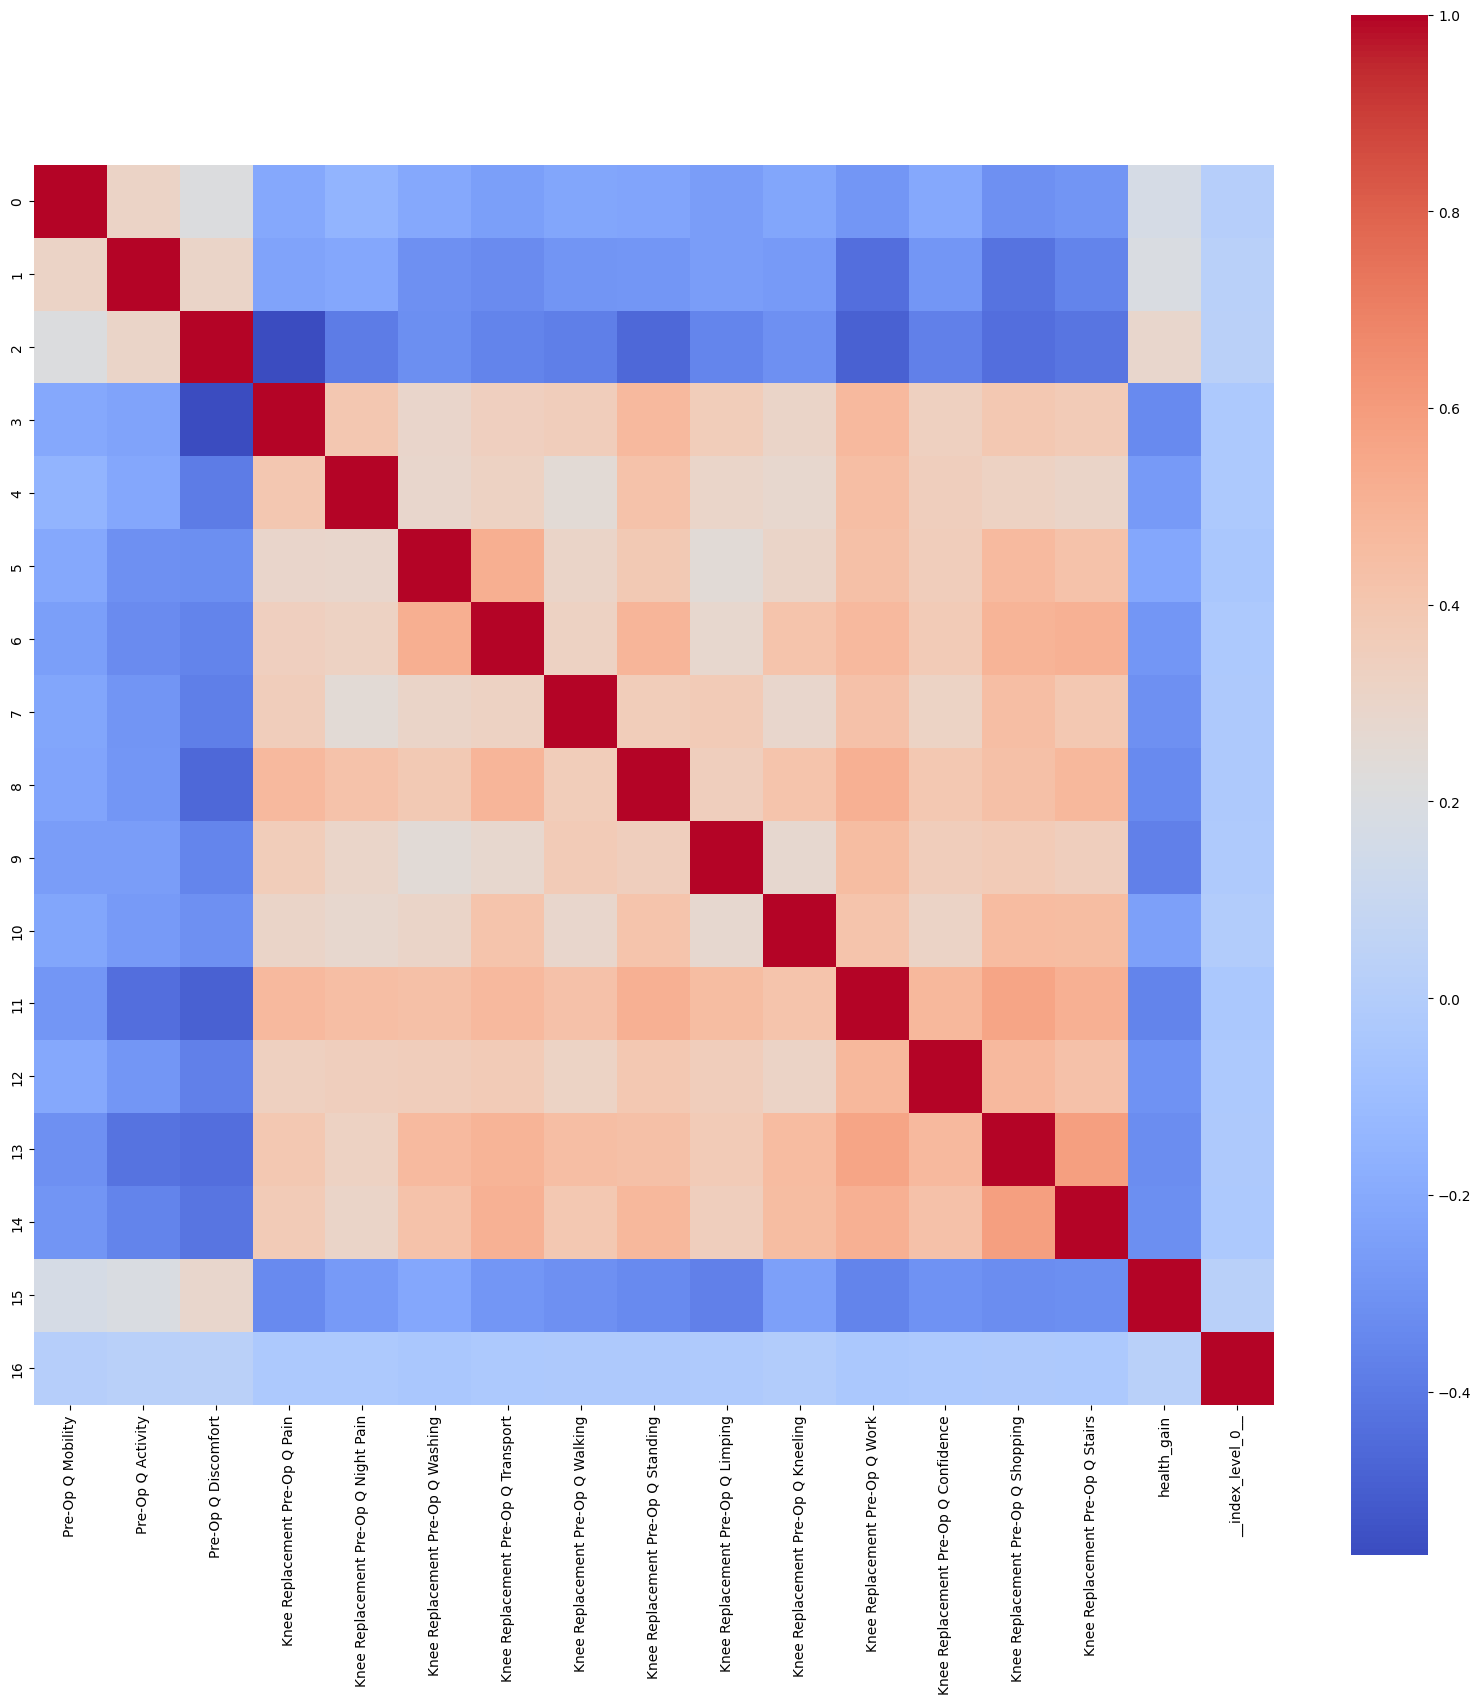

In [77]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_reduced.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix.to_pandas(),
    annot=False,
    square=True,
    cmap='coolwarm'
)

<Axes: >

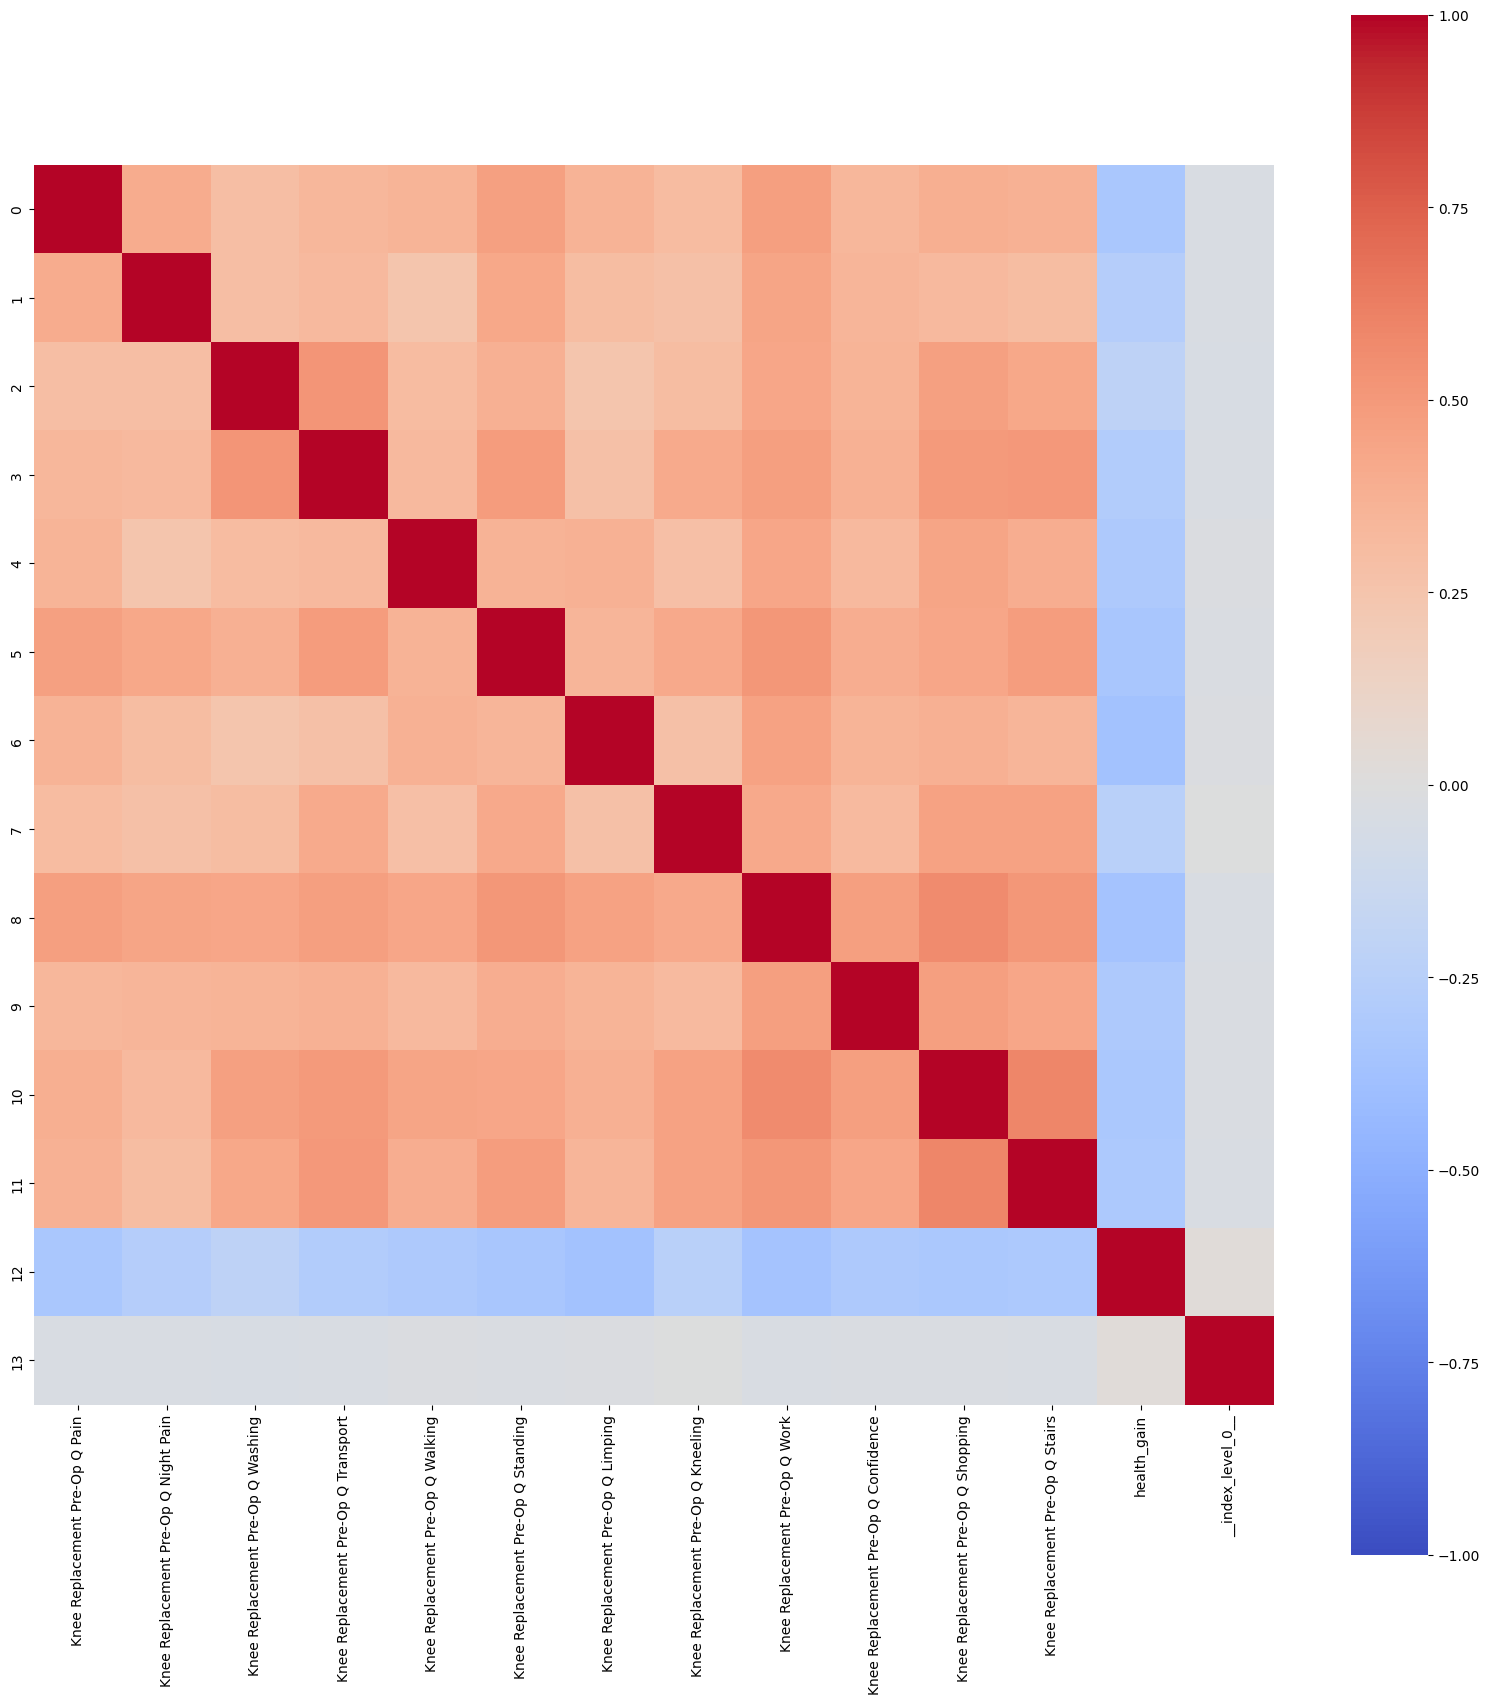

In [35]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix.to_pandas(),
    annot=False,
    square=True,
    cmap='coolwarm',
    vmin=-1,   # force full correlation range
    vmax=1,
    center=0   # ensure 0 is the midpoint (grey)
)


In [7]:
target = "health_gain"

numeric_features = (
    df_reduced
    .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))
    .columns
)

corr_overview = df.select([
    pl.corr(pl.col(target), pl.col(feature)).alias(feature)
    for feature in numeric_features
]).transpose(include_header=True, header_name="feature", column_names=["correlation"])

corr_overview = corr_overview.sort("correlation", descending=True)

corr_overview.show(50)

print(corr_overview)




C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\773840197.py:5: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))


feature,correlation
str,f64
"""Pre-Op Q Discomfort""",0.285882
"""Pre-Op Q Activity""",0.196738
"""Pre-Op Q Mobility""",0.17315
"""__index_level_0__""",0.027226
"""Knee Replacement Pre-Op Q Wash…",-0.216968
"""Knee Replacement Pre-Op Q Knee…",-0.247192
"""Knee Replacement Pre-Op Q Nigh…",-0.268005
"""Knee Replacement Pre-Op Q Tran…",-0.285361
"""Knee Replacement Pre-Op Q Conf…",-0.304716


shape: (16, 2)
┌─────────────────────────────────┬─────────────┐
│ feature                         ┆ correlation │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ Pre-Op Q Discomfort             ┆ 0.285882    │
│ Pre-Op Q Activity               ┆ 0.196738    │
│ Pre-Op Q Mobility               ┆ 0.17315     │
│ __index_level_0__               ┆ 0.027226    │
│ Knee Replacement Pre-Op Q Wash… ┆ -0.216968   │
│ …                               ┆ …           │
│ Knee Replacement Pre-Op Q Shop… ┆ -0.323322   │
│ Knee Replacement Pre-Op Q Pain  ┆ -0.333731   │
│ Knee Replacement Pre-Op Q Stan… ┆ -0.338922   │
│ Knee Replacement Pre-Op Q Work  ┆ -0.363248   │
│ Knee Replacement Pre-Op Q Limp… ┆ -0.37382    │
└─────────────────────────────────┴─────────────┘


In [8]:
corrs = df_reduced.select([
    pl.corr(pl.col(target), pl.col(col)).alias(col)
    for col in df_reduced.columns
    if col != target
]).transpose(
    include_header=True,
    header_name="feature",
    column_names=["correlation"]
)

corrs

feature,correlation
str,f64
"""Pre-Op Q Mobility""",0.17315
"""Pre-Op Q Activity""",0.196738
"""Pre-Op Q Discomfort""",0.285882
"""Knee Replacement Pre-Op Q Pain""",-0.333731
"""Knee Replacement Pre-Op Q Nigh…",-0.268005
…,…
"""Knee Replacement Pre-Op Q Work""",-0.363248
"""Knee Replacement Pre-Op Q Conf…",-0.304716
"""Knee Replacement Pre-Op Q Shop…",-0.323322


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

target = "health_gain"

# Prepare data
X = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()
y = df_reduced[target].to_numpy()

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = model.score(X, y)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R²: 0.23838257513616612
RMSE: 8.362063440359108
MAE: 6.634404208629279


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\4286161712.py:8: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  X = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

target = "health_gain"

# Prepare data
X = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()
y = df_reduced[target].to_numpy()

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = model.score(X, y)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R²: 0.23838257513616612
RMSE: 8.362063440359108
MAE: 6.634404208629279


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\4286161712.py:8: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  X = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()


In [11]:
feature_names = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).columns

for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef}")

print("Intercept:", model.intercept_)


Pre-Op Q Mobility: 0.18102634847069576
Pre-Op Q Activity: -0.28275091380737366
Pre-Op Q Discomfort: -0.4202438384739654
Knee Replacement Pre-Op Q Pain: -1.545168818427291
Knee Replacement Pre-Op Q Night Pain: -0.3457130688267499
Knee Replacement Pre-Op Q Washing: 0.30375242833858057
Knee Replacement Pre-Op Q Transport: -0.5426574903381148
Knee Replacement Pre-Op Q Walking: -0.753757935594812
Knee Replacement Pre-Op Q Standing: -0.9337321508228233
Knee Replacement Pre-Op Q Limping: -1.767576130168268
Knee Replacement Pre-Op Q Kneeling: -0.12148019149299341
Knee Replacement Pre-Op Q Work: -0.6781451069983905
Knee Replacement Pre-Op Q Confidence: -0.5478355247997334
Knee Replacement Pre-Op Q Shopping: -0.2756464235094217
Knee Replacement Pre-Op Q Stairs: -0.5016425328607487
__index_level_0__: 2.094572096274546e-06
Intercept: 27.94450629764056


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\596584966.py:1: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  feature_names = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).columns


In [12]:
low_corr_cols_2 = [
    "Gender",
    "Pre-Op Q Anxiety",
    "Arthritis",
    "Age Band",
    "Pre-Op Q Symptom Period",
    "High Bp",
    "Cancer",
    "Nervous System",
    "Lung Disease",
    "Liver Disease",
    "Kidney Disease",
    "Stroke",
    "Pre-Op Q Living Arrangements",
    "Heart Disease",
    "Pre-Op Q Disability",
    "Depression",
    "Diabetes",
    "Pre-Op Q Assisted",
    "Circulation",
    "Revision Flag",
    "Pre-Op Q Self-Care",	
    "Pre-Op Q Previous Surgery",
     "Pre-Op Q Discomfort",
     "Pre-Op Q Activity",
     "Pre-Op Q Mobility"  
]


df_kneepres = df.drop(low_corr_cols_2)

df_kneepres.columns



['Knee Replacement Pre-Op Q Pain',
 'Knee Replacement Pre-Op Q Night Pain',
 'Knee Replacement Pre-Op Q Washing',
 'Knee Replacement Pre-Op Q Transport',
 'Knee Replacement Pre-Op Q Walking',
 'Knee Replacement Pre-Op Q Standing',
 'Knee Replacement Pre-Op Q Limping',
 'Knee Replacement Pre-Op Q Kneeling',
 'Knee Replacement Pre-Op Q Work',
 'Knee Replacement Pre-Op Q Confidence',
 'Knee Replacement Pre-Op Q Shopping',
 'Knee Replacement Pre-Op Q Stairs',
 'health_gain',
 '__index_level_0__']

In [13]:
numeric_features = (
    df_kneepres
    .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))
    .columns
)

corr_overview = df_kneepres.select([
    pl.corr(pl.col(target), pl.col(feature)).alias(feature)
    for feature in numeric_features
]).transpose(include_header=True, header_name="feature", column_names=["correlation"])

corr_overview = corr_overview.sort("correlation", descending=True)

corr_overview.show(50)

print(corr_overview)




C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\2081124126.py:3: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))


feature,correlation
str,f64
"""__index_level_0__""",0.027226
"""Knee Replacement Pre-Op Q Wash…",-0.216968
"""Knee Replacement Pre-Op Q Knee…",-0.247192
"""Knee Replacement Pre-Op Q Nigh…",-0.268005
"""Knee Replacement Pre-Op Q Tran…",-0.285361
"""Knee Replacement Pre-Op Q Conf…",-0.304716
"""Knee Replacement Pre-Op Q Walk…",-0.309346
"""Knee Replacement Pre-Op Q Stai…",-0.317599
"""Knee Replacement Pre-Op Q Shop…",-0.323322


shape: (13, 2)
┌─────────────────────────────────┬─────────────┐
│ feature                         ┆ correlation │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ __index_level_0__               ┆ 0.027226    │
│ Knee Replacement Pre-Op Q Wash… ┆ -0.216968   │
│ Knee Replacement Pre-Op Q Knee… ┆ -0.247192   │
│ Knee Replacement Pre-Op Q Nigh… ┆ -0.268005   │
│ Knee Replacement Pre-Op Q Tran… ┆ -0.285361   │
│ …                               ┆ …           │
│ Knee Replacement Pre-Op Q Shop… ┆ -0.323322   │
│ Knee Replacement Pre-Op Q Pain  ┆ -0.333731   │
│ Knee Replacement Pre-Op Q Stan… ┆ -0.338922   │
│ Knee Replacement Pre-Op Q Work  ┆ -0.363248   │
│ Knee Replacement Pre-Op Q Limp… ┆ -0.37382    │
└─────────────────────────────────┴─────────────┘


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

target = "health_gain"

# Prepare data
X = df_kneepres.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()
y = df_kneepres[target].to_numpy()

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = model.score(X, y)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R²: 0.23794514700625824
RMSE: 8.3644644336911
MAE: 6.635785716790663


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\164972124.py:8: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  X = df_kneepres.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()


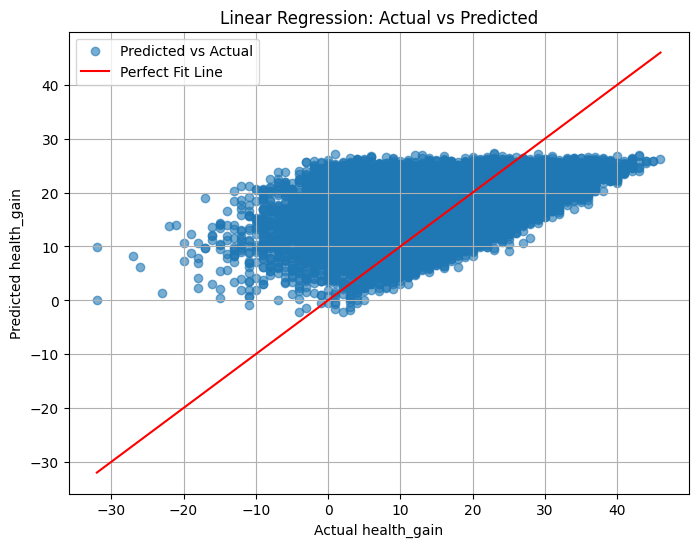

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions (model and X must already exist from your regression code)
y_pred = model.predict(X)

plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted
plt.scatter(y, y_pred, alpha=0.6, label="Predicted vs Actual")

# Perfect prediction line
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", label="Perfect Fit Line")

plt.xlabel("Actual health_gain")
plt.ylabel("Predicted health_gain")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


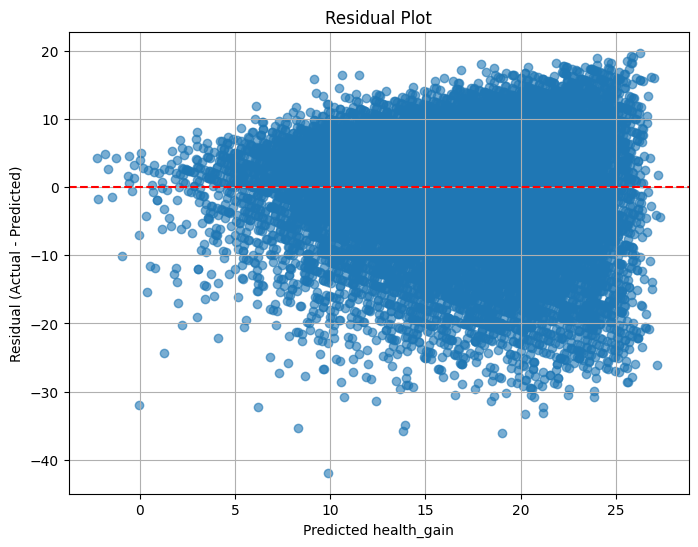

In [16]:
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X)

# Residuals
residuals = y - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted health_gain")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

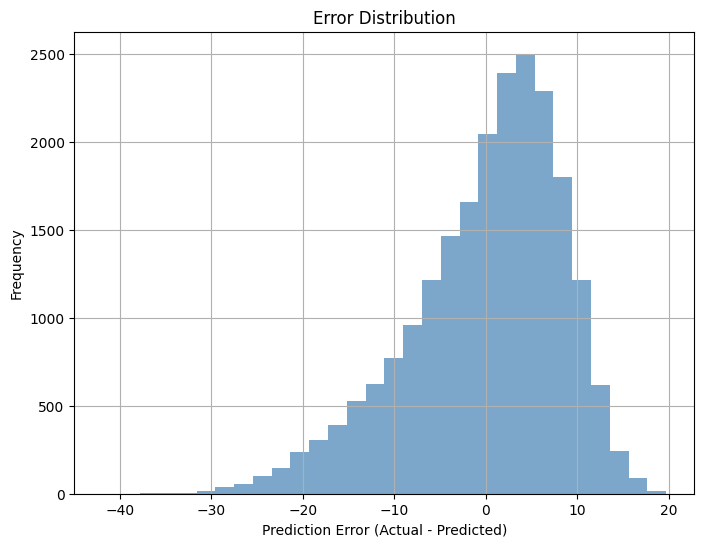

In [17]:
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X)

# Errors
errors = y - y_pred

plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, alpha=0.7, color="steelblue")

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.grid(True)
plt.show()



What does a negative residual mean?
Residual = Actual − Predicted

So:

Negative residual → Actual < Predicted
→ The model overestimates the outcome

Positive residual → Actual > Predicted
→ The model underestimates the outcome

If your residual plot and error histogram show more negative residuals, then:

👉 Your model is systematically predicting values that are too high.
This is called systematic overprediction or bias.

C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\4009879020.py:5: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  feature_names = df_kneepres.select(pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")).columns


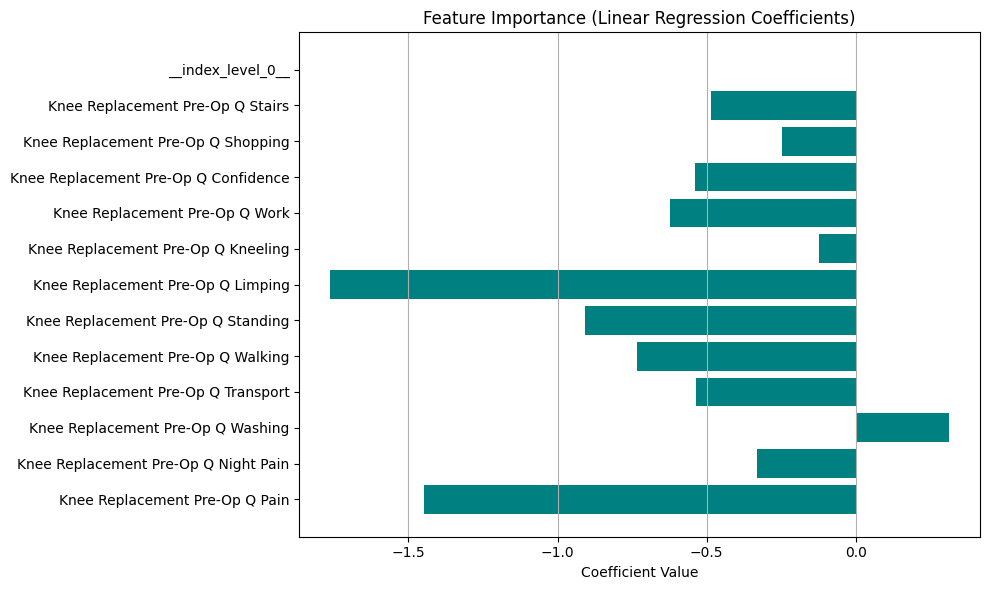

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names
feature_names = df_kneepres.select(pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")).columns

# Coefficients
coefs = model.coef_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefs, color="teal")
plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.grid(True, axis="x")
plt.tight_layout()
plt.show()


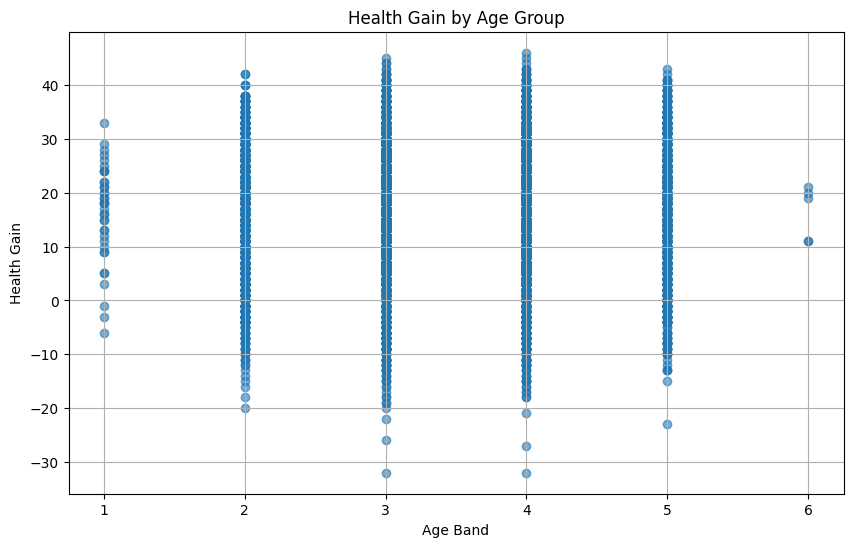

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plot: health_gain vs Age Band
plt.scatter(df["Age Band"], df["health_gain"], alpha=0.6)



plt.xlabel("Age Band")
plt.ylabel("Health Gain")
plt.title("Health Gain by Age Group")
plt.grid(True)
plt.show()

In [20]:
df = df.with_columns([
    pl.col("Age Band").cast(pl.Utf8),
    pl.col("health_gain").cast(pl.Float64)
])

import polars as pl

# Ensure correct types
df = df.with_columns([
    pl.col("Age Band").cast(pl.Categorical),
    pl.col("health_gain").cast(pl.Float64)
])

# Basic stats
stats = (
    df.group_by("Age Band")
      .agg([
          pl.col("health_gain").mean().alias("mean"),
          pl.col("health_gain").median().alias("median"),
          pl.col("health_gain").std().alias("std")
      ])
)

# Mode (Polars returns a list)
mode_df = (
    df.group_by("Age Band")
      .agg(pl.col("health_gain").mode().alias("mode"))
      .with_columns(pl.col("mode").list.get(0).alias("mode"))
)

# Join mode into stats
stats = stats.join(mode_df, on="Age Band")

print(stats)


# Join mode into stats
stats = stats.join(mode_df, on="Age Band")

stats = stats.sort("Age Band", descending=False)


print(stats)




shape: (6, 5)
┌──────────┬───────────┬────────┬──────────┬──────┐
│ Age Band ┆ mean      ┆ median ┆ std      ┆ mode │
│ ---      ┆ ---       ┆ ---    ┆ ---      ┆ ---  │
│ cat      ┆ f64       ┆ f64    ┆ f64      ┆ f64  │
╞══════════╪═══════════╪════════╪══════════╪══════╡
│ 2.0      ┆ 16.601399 ┆ 17.0   ┆ 9.944104 ┆ 21.0 │
│ 4.0      ┆ 17.044578 ┆ 17.0   ┆ 9.44722  ┆ 19.0 │
│ 3.0      ┆ 16.845333 ┆ 17.0   ┆ 9.627343 ┆ 18.0 │
│ 6.0      ┆ 16.4      ┆ 19.0   ┆ 4.97996  ┆ 11.0 │
│ 5.0      ┆ 17.1268   ┆ 18.0   ┆ 9.603396 ┆ 22.0 │
│ 1.0      ┆ 16.236842 ┆ 18.0   ┆ 9.032776 ┆ 18.0 │
└──────────┴───────────┴────────┴──────────┴──────┘
shape: (6, 6)
┌──────────┬───────────┬────────┬──────────┬──────┬────────────┐
│ Age Band ┆ mean      ┆ median ┆ std      ┆ mode ┆ mode_right │
│ ---      ┆ ---       ┆ ---    ┆ ---      ┆ ---  ┆ ---        │
│ cat      ┆ f64       ┆ f64    ┆ f64      ┆ f64  ┆ f64        │
╞══════════╪═══════════╪════════╪══════════╪══════╪════════════╡
│ 1.0      ┆ 16.236842 

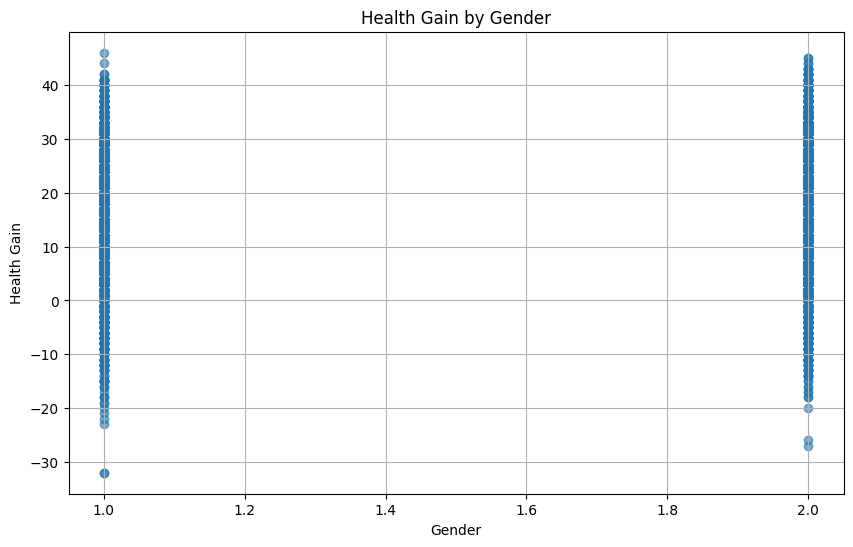

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plot: health_gain vs Age Band
plt.scatter(df["Gender"], df["health_gain"], alpha=0.6)



plt.xlabel("Gender")
plt.ylabel("Health Gain")
plt.title("Health Gain by Gender")
plt.grid(True)
plt.show()

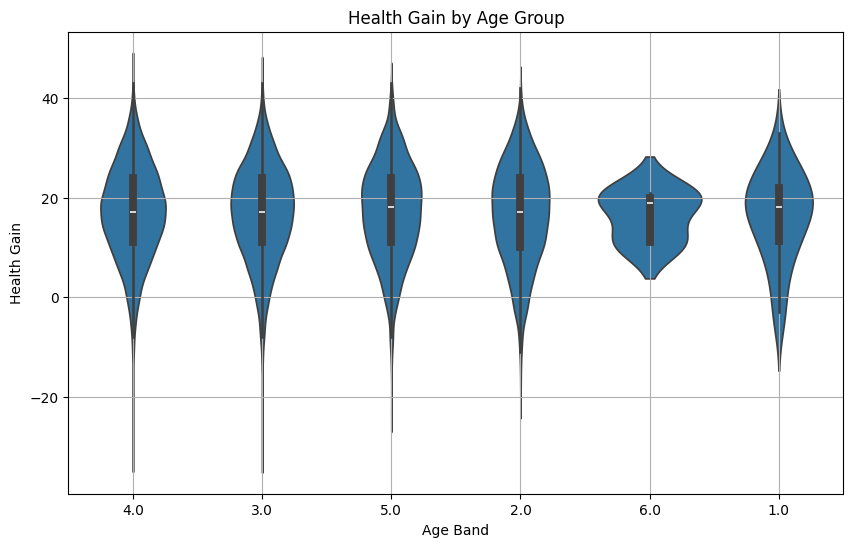

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pandas = df.to_pandas()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_pandas, x="Age Band", y="health_gain")

plt.title("Health Gain by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Health Gain")
plt.grid(True)
plt.show()


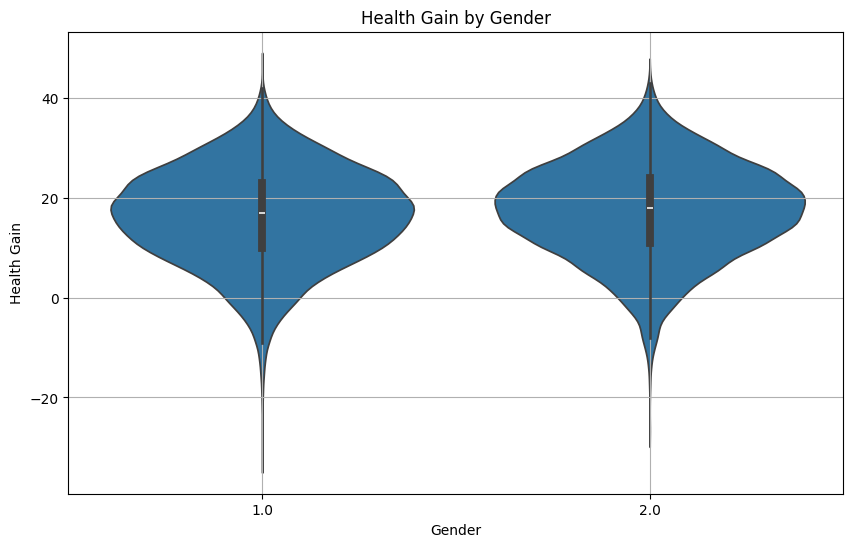

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pandas = df.to_pandas()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_pandas, x="Gender", y="health_gain")

plt.title("Health Gain by Gender")
plt.xlabel("Gender")
plt.ylabel("Health Gain")
plt.grid(True)
plt.show()

In [24]:
df["Age Band"].value_counts()


Age Band,count
cat,u32
"""1.0""",38
"""5.0""",2500
"""2.0""",2288
"""3.0""",7778
"""4.0""",9130
"""6.0""",5


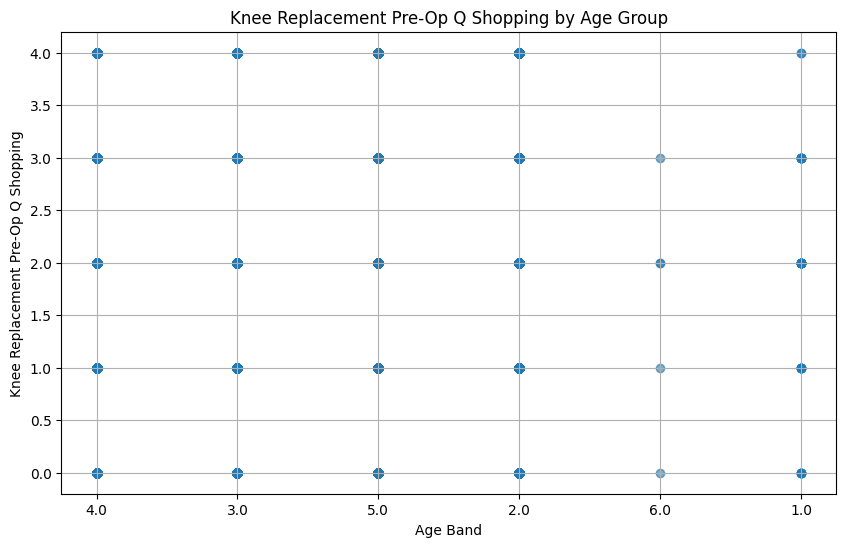

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plot: health_gain vs Age Band
plt.scatter(df["Age Band"], df["Knee Replacement Pre-Op Q Shopping"], alpha=0.6)



plt.xlabel("Age Band")
plt.ylabel("Knee Replacement Pre-Op Q Shopping")
plt.title("Knee Replacement Pre-Op Q Shopping by Age Group")
plt.grid(True)
plt.show()

In [26]:
df.select([
    pl.col("Age Band"),
    pl.col("Knee Replacement Pre-Op Q Shopping")
]).group_by(["Age Band", "Knee Replacement Pre-Op Q Shopping"]).count().sort(["Age Band"])

pl.Config.set_tbl_rows(50)   # show up to 50 rows

df.group_by(["Age Band", "Knee Replacement Pre-Op Q Shopping"]) \
  .count() \
  .sort(["Age Band", "Knee Replacement Pre-Op Q Shopping"])



C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\25615452.py:4: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  ]).group_by(["Age Band", "Knee Replacement Pre-Op Q Shopping"]).count().sort(["Age Band"])
C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\25615452.py:9: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count() \


Age Band,Knee Replacement Pre-Op Q Shopping,count
cat,f64,u32
"""1.0""",0.0,6
"""1.0""",1.0,7
"""1.0""",2.0,14
"""1.0""",3.0,9
"""1.0""",4.0,2
"""2.0""",0.0,323
"""2.0""",1.0,466
"""2.0""",2.0,787
"""2.0""",3.0,460


In [27]:
from sklearn.linear_model import LassoCV
import polars as pl
import numpy as np


# 2. Select numeric predictors (excluding the outcome)
X = df_kneepres.select(
    pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
).to_numpy()

# 3. Outcome variable
y = df_kneepres["health_gain"].to_numpy()

# 4. Fit Lasso with cross-validation to find best alpha
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)

# 5. Print results
print("Best alpha (regularization strength):", lasso.alpha_)

feature_names = df_kneepres.select(
    pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
).columns

print("\nLasso Coefficients:")
for name, coef in zip(feature_names, lasso.coef_):
    print(f"{name}: {coef:.2f}")


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\2915526778.py:8: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


Best alpha (regularization strength): 10.384732425116328

Lasso Coefficients:
Knee Replacement Pre-Op Q Pain: 0.00
Knee Replacement Pre-Op Q Night Pain: -0.00
Knee Replacement Pre-Op Q Washing: 0.00
Knee Replacement Pre-Op Q Transport: 0.00
Knee Replacement Pre-Op Q Walking: 0.00
Knee Replacement Pre-Op Q Standing: 0.00
Knee Replacement Pre-Op Q Limping: 0.00
Knee Replacement Pre-Op Q Kneeling: 0.00
Knee Replacement Pre-Op Q Work: 0.00
Knee Replacement Pre-Op Q Confidence: -0.00
Knee Replacement Pre-Op Q Shopping: -0.00
Knee Replacement Pre-Op Q Stairs: 0.00
__index_level_0__: 0.00


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\2915526778.py:22: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\483906263.py:7: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


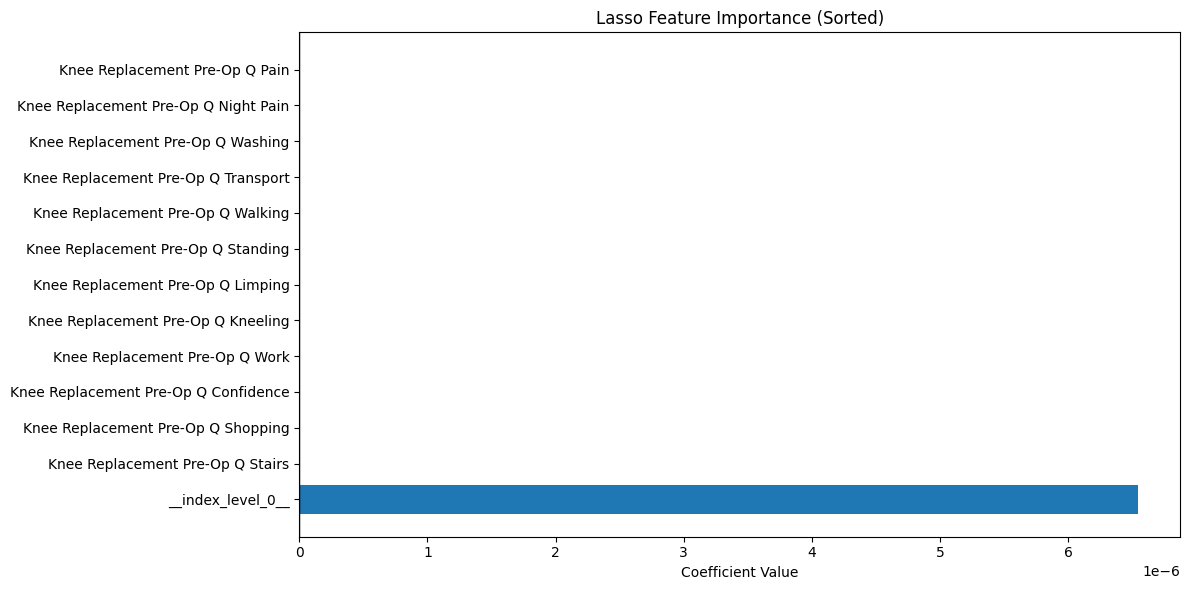

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Feature names
feature_names = np.array(
    df_kneepres.select(
        pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
    ).columns
)

coefs = np.array(lasso.coef_)

# Sort by absolute coefficient value
idx = np.argsort(np.abs(coefs))[::-1]

plt.figure(figsize=(12, 6))
plt.barh(feature_names[idx], coefs[idx])
plt.xlabel("Coefficient Value")
plt.title("Lasso Feature Importance (Sorted)")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


<Axes: >

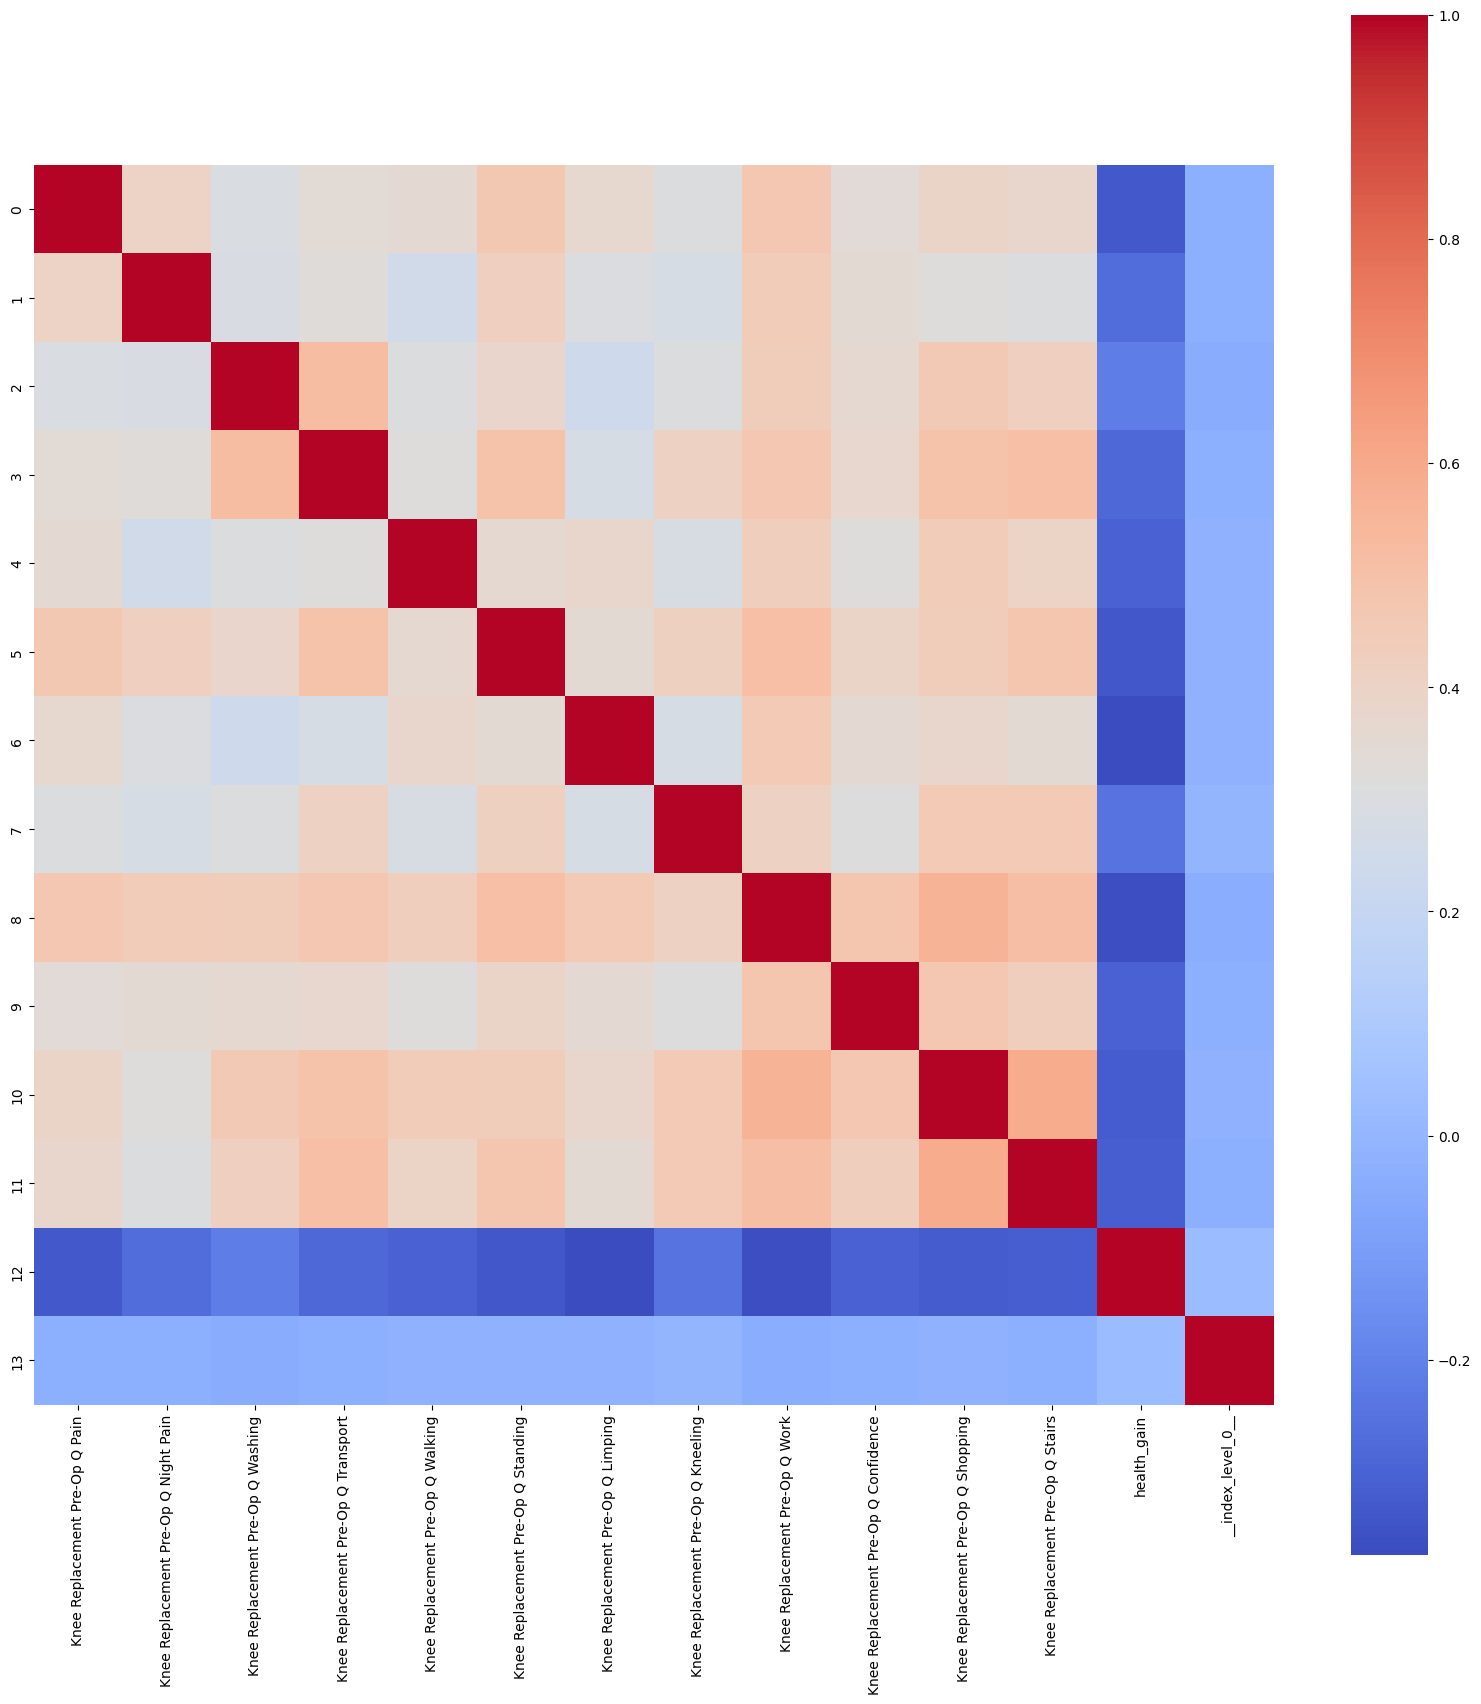

In [29]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_kneepres.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix.to_pandas(),
    annot=False,
    square=True,
    cmap='coolwarm'
)

In [30]:
from sklearn.preprocessing import StandardScaler
import polars as pl
import numpy as np

# 1. Select numeric predictors (excluding the outcome)
X_df = df.select(
    pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
)

# 2. Convert to numpy for scaling
X = X_df.to_numpy()

# 3. Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Outcome variable (not scaled)
y = df["health_gain"].to_numpy()

# 5. Rebuild a standardized dataframe (optional but useful)
df_standardized = pl.DataFrame(
    X_scaled,
    schema=X_df.columns
).with_columns(
    pl.Series("health_gain", y)
)


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\1169873529.py:7: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


In [31]:
from sklearn.linear_model import LassoCV

# Select predictors again (now standardized)
X = df_standardized.select(
    pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
).to_numpy()

y = df_standardized["health_gain"].to_numpy()

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)

print("Best alpha:", lasso.alpha_)



C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\3963991133.py:5: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


Best alpha: 0.020496644060325177


C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\157510827.py:6: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


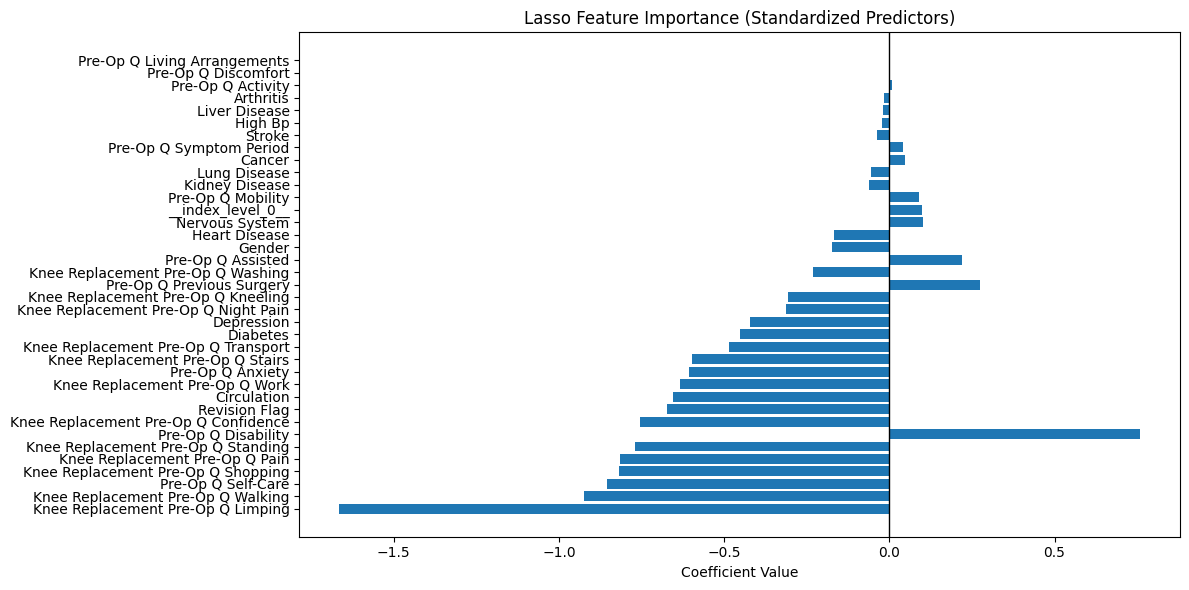

In [32]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = np.array(
    df_standardized.select(
        pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
    ).columns
)

coefs = np.array(lasso.coef_)

# Sort by absolute value
idx = np.argsort(np.abs(coefs))[::-1]

plt.figure(figsize=(12, 6))
plt.barh(feature_names[idx], coefs[idx])
plt.xlabel("Coefficient Value")
plt.title("Lasso Feature Importance (Standardized Predictors)")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()



C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\2148666987.py:7: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


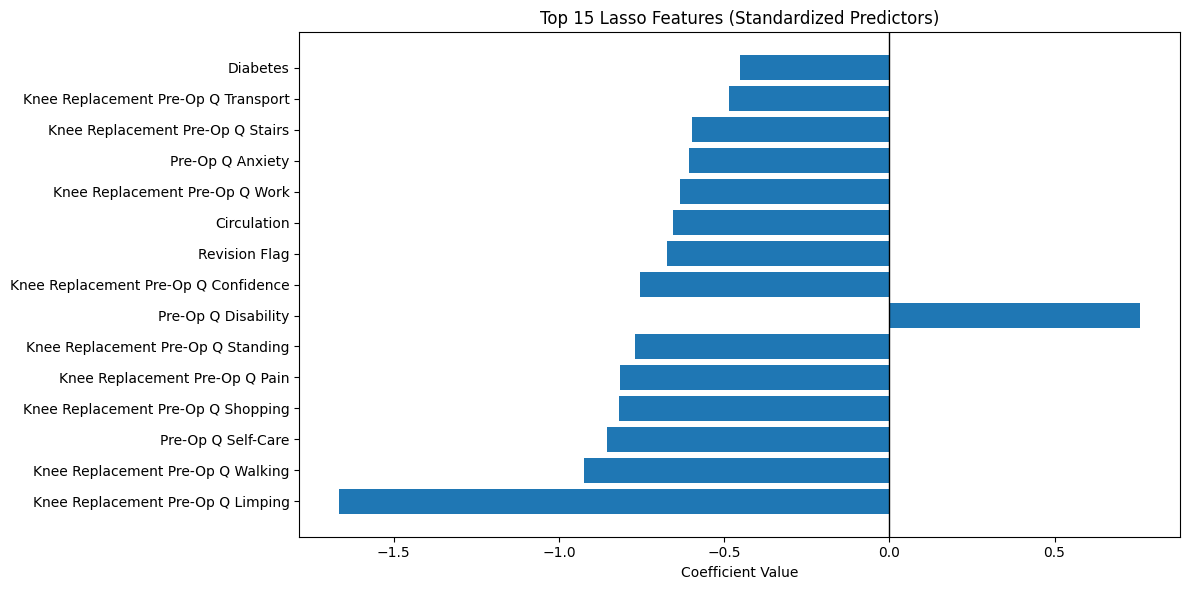

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature names and coefficients
feature_names = np.array(
    df_standardized.select(
        pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
    ).columns
)
coefs = np.array(lasso.coef_)

# Sort by absolute value
idx = np.argsort(np.abs(coefs))[::-1]

# Select top 15
top_n = 15
top_idx = idx[:top_n]

plt.figure(figsize=(12, 6))
plt.barh(feature_names[top_idx], coefs[top_idx])
plt.xlabel("Coefficient Value")
plt.title("Top 15 Lasso Features (Standardized Predictors)")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


In [34]:
import polars as pl
from scipy.stats import ttest_ind

# --- 1. Ensure correct types ---
df = df.with_columns([
    pl.col("Age Band").cast(pl.Int64),
    pl.col("health_gain").cast(pl.Float64)
])

# --- 2. T-test: group 6 vs all other groups ---

# Extract values as Python lists
group6 = df.filter(pl.col("Age Band") == 6)["health_gain"].to_list()
others = df.filter(pl.col("Age Band") != 6)["health_gain"].to_list()

# Run Welch's t-test (recommended for unequal variances)
t_stat, p_value = ttest_ind(group6, others, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# --- 3. Create dummy variables in a NEW dataframe ---

# Convert Age Band to categorical for one-hot encoding
df_dummies = df.with_columns(
    pl.col("Age Band").cast(pl.Categorical)
).to_dummies(columns=["Age Band"])

print(df_dummies)


T-statistic: nan
P-value: nan
shape: (21_739, 44)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Revision  ┆ Age       ┆ Age       ┆ Age       ┆ … ┆ Knee Repl ┆ Knee Repl ┆ health_ga ┆ __index_ │
│ Flag      ┆ Band_1.0  ┆ Band_2.0  ┆ Band_3.0  ┆   ┆ acement   ┆ acement   ┆ in        ┆ level_0_ │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ ---       ┆ _        │
│ u8        ┆ u8        ┆ u8        ┆ u8        ┆   ┆ Shop…     ┆ Stai…     ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ ---       ┆ ---       ┆           ┆ i64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 4.0       ┆ 3.0       ┆ 18.0      ┆ 99471    │
│ 0         ┆ 0         ┆ 0         ┆ 0  

C:\Users\jkrin\AppData\Local\Temp\ipykernel_10504\3665077526.py:17: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = ttest_ind(group6, others, equal_var=False)
